# SVM

## Imortação dos dados

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

# 1. Carregar o conjunto de dados
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# 2. Dividir o conjunto de dados em treinamento e teste [cite: 5]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Pré-processamento: Escalonar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Cálculo das acurácias

In [8]:
# 4. Treinar o modelo SVM variando o parâmetro C e calcular acurácia [cite: 3, 6]
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 5000, 10000]
accuracies = []

print("Acurácia para diferentes valores de C (todas as features):")
for C_val in C_values:
    # Usar kernel RBF que é um bom kernel de propósito geral
    svm_model = SVC(C=C_val, kernel='rbf', random_state=42, probability=True)
    svm_model.fit(X_train_scaled, y_train)
    y_pred = svm_model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"C = {C_val:.3f}: Acurácia = {acc:.4f}")

Acurácia para diferentes valores de C (todas as features):
C = 0.001: Acurácia = 0.6316
C = 0.010: Acurácia = 0.6316
C = 0.100: Acurácia = 0.9474
C = 1.000: Acurácia = 0.9825
C = 10.000: Acurácia = 0.9737
C = 100.000: Acurácia = 0.9474
C = 1000.000: Acurácia = 0.9474
C = 5000.000: Acurácia = 0.9474
C = 10000.000: Acurácia = 0.9474


### Gráfico

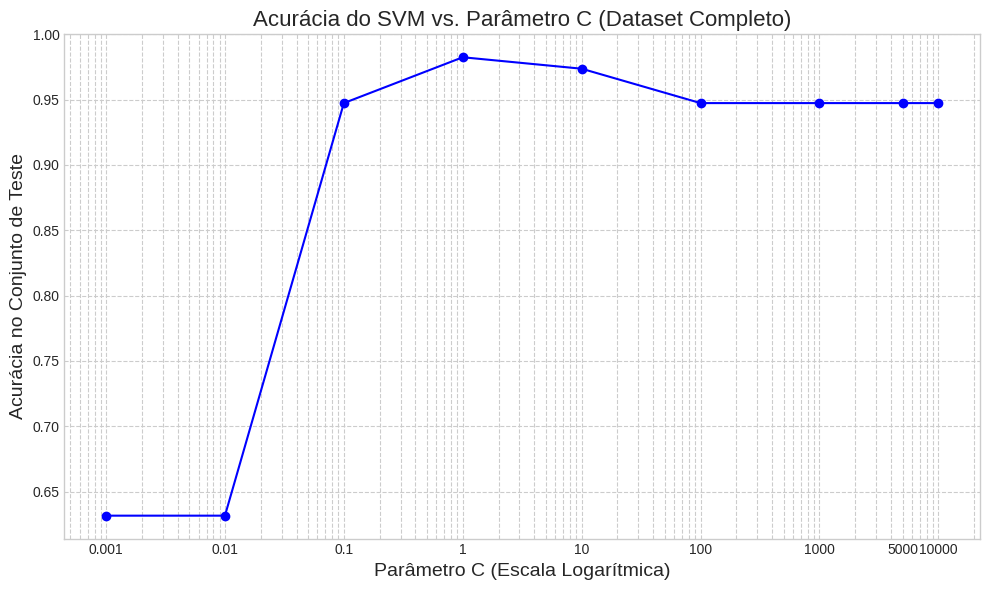

In [9]:

# 5. Gerar gráfico de acurácia dos modelos [cite: 4]
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))
plt.plot(C_values, accuracies, marker='o', linestyle='-', color='b')
plt.xscale('log')
plt.title('Acurácia do SVM vs. Parâmetro C (Dataset Completo)', fontsize=16)
plt.xlabel('Parâmetro C (Escala Logarítmica)', fontsize=14)
plt.ylabel('Acurácia no Conjunto de Teste', fontsize=14)
plt.xticks(C_values, labels=[str(val) for val in C_values])
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

## Superficies de separação

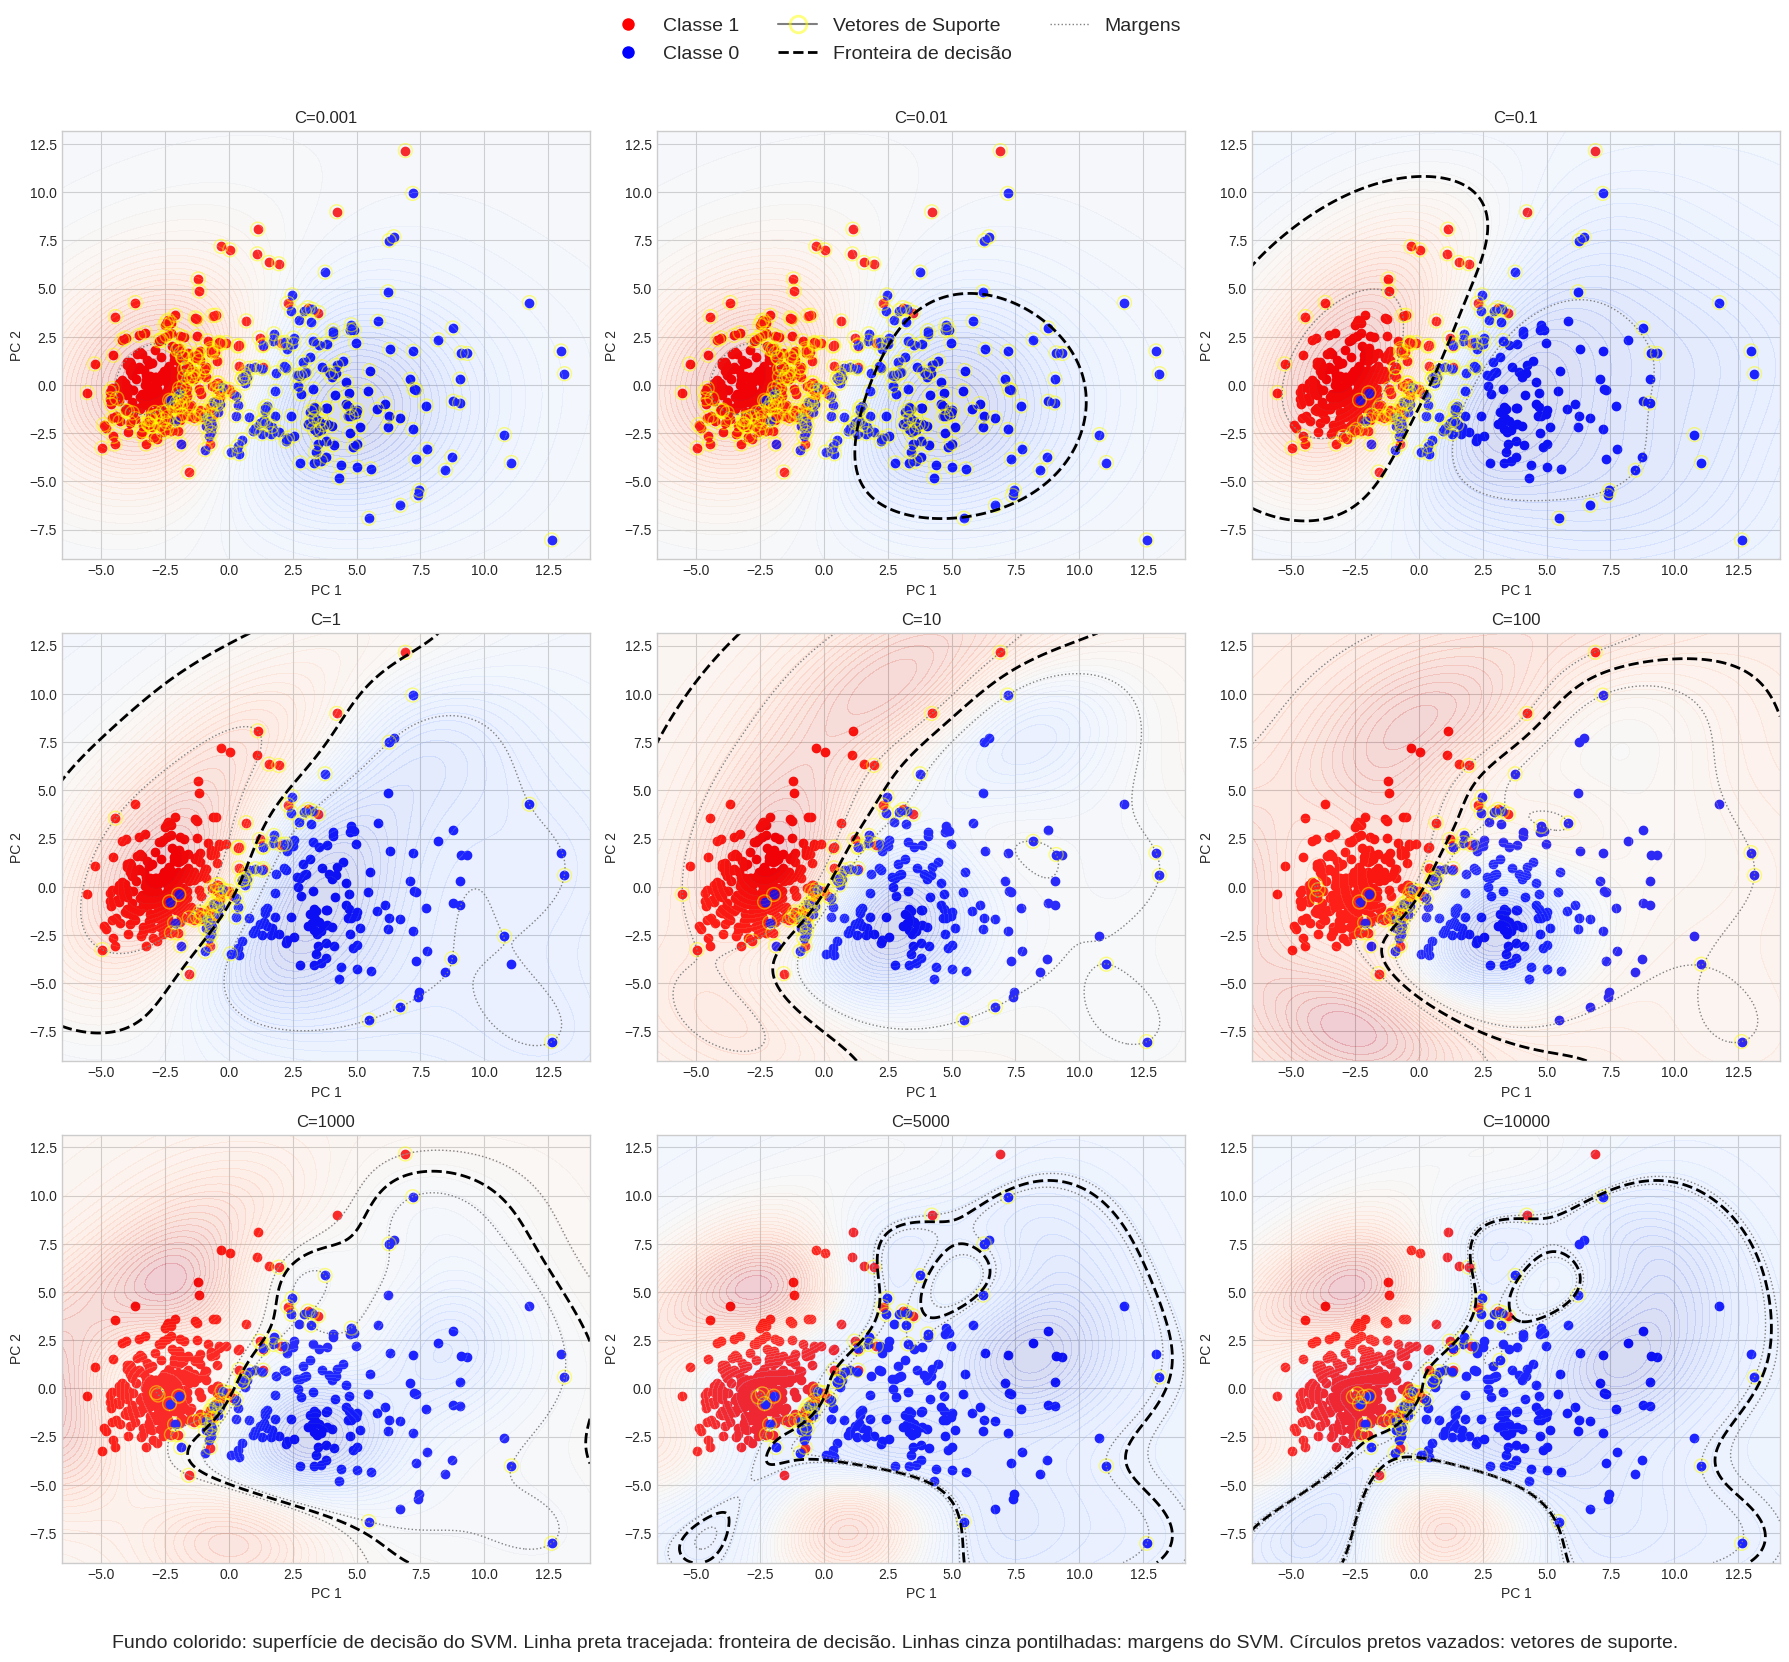

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.decomposition import PCA

# Supondo que X_train_scaled, y_train, e C_values já existem

# Reduzir para 2D com PCA
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()  # Facilita o acesso por índice

for i, C_val in enumerate(C_values):
    svm = SVC(C=C_val, kernel='rbf', random_state=42)
    svm.fit(X_train_pca, y_train)
    
    ax = axes[i]
    # Plot dos pontos das duas classes
    scatter1 = ax.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], color='red', label='Classe 1')
    scatter0 = ax.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], color='blue', label='Classe 0')
    
    # Superfície de decisão
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Fundo colorido
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), Z.max(), 50), cmap=plt.cm.coolwarm, alpha=0.2)
    # Fronteira de decisão
    contour_decision = ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='k', linestyles='--')
    # Margens
    contour_margins = ax.contour(xx, yy, Z, levels=[-1, 1], linewidths=1, colors='grey', linestyles=':')
    
    # Vetores de suporte
    support_vectors = svm.support_vectors_
    scatter_sv = ax.scatter(support_vectors[:, 0], support_vectors[:, 1], 
                            color='black', edgecolor='yellow', 
                            label='Vetores de Suporte', s=100, marker='o', facecolors='none', alpha=0.5)
    
    ax.set_title(f'C={C_val}')
    ax.set_xlabel('PC 1')
    ax.set_ylabel('PC 2')
    ax.grid(True)

# Legenda única fora dos subplots
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Classe 1', markerfacecolor='red', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Classe 0', markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='o', color='black', label='Vetores de Suporte', markerfacecolor='none', markeredgewidth=2, markeredgecolor='yellow', markersize=12, alpha=0.5),
    plt.Line2D([0], [0], color='k', linestyle='--', linewidth=2, label='Fronteira de decisão'),
    plt.Line2D([0], [0], color='grey', linestyle=':', linewidth=1, label='Margens')
]
fig.legend(handles=handles, loc='upper center', ncol=3, fontsize=14, bbox_to_anchor=(0.5, 1.04))

# Anotação explicativa abaixo dos gráficos
fig.text(0.5, 0.01,
         "Fundo colorido: superfície de decisão do SVM. "
         "Linha preta tracejada: fronteira de decisão. "
         "Linhas cinza pontilhadas: margens do SVM. "
         "Círculos pretos vazados: vetores de suporte.",
         ha='center', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])  # Ajusta para não sobrepor a legenda
plt.show()

É possivel perceber que com valores pequenos de C o modelo tem margens suaves e tem uma grande quantidade de pontos classificados errados. Na medida que o C vai aumentando essa fronteira vai se conformando melhor aos dados e isso se reflete na acurácia. A acurácia maxima acontece com C=1. A partir disso, ao aumentar o C, a fronteira vai ficando mais complexa e vai criando até novas fronteiras dentro dela mesma. O modelo tenta prever todos os pontos corretamente. O problema com isso é que ele tenta prever tão corretamente os pontos de treino que acaba prevendo mal os de teste. Com C baixo o modelo mostra under-fitting e com C alto o modelo mostra over-fitting.